In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path('data\ml-latest-small')
SEED = 42 
K_VALUES = [5, 10, 20, 50]
METHODS = ['user', 'item']
MIN_CO_RATED = 2

## Student-written conventions

TODO: Record your split rounding rule, undefined-case policy, tie-breaking and data folder choice.

## Part A — Load and explore (5 points) — A

1. Load `ratings.csv` and `movies.csv` into DataFrames.
2. Report unique users, unique movies, rating count and matrix sparsity. State which movie population defines the denominator.
3. Build the user–movie matrix: user IDs as rows, movie IDs as columns, ratings as values, missing entries as NaN.
4. Plot **or print** rating frequencies and the distribution of how many ratings each user gives. Write observations.

Checks: inspect data types and duplicate user/movie pairs; verify the matrix NaN fraction agrees with your stated sparsity calculation. The full matrix is for exploration; evaluation must use a separate training matrix.

In [4]:
movies = pd.read_csv(DATA_DIR / "movies.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")

unique_movies = movies["movieId"].nunique()
unique_users = ratings['userId'].nunique()
total_ratings = len(ratings)

matrix_sparsity = 1 - (total_ratings / (unique_users * unique_movies))

full_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

nan_fraction = full_matrix.isna().sum().sum() / full_matrix.size

print(f"Total Ratings: {total_ratings}")
print(f"Unique Users: {unique_users}")
print(f"Unique Movies: {unique_movies}")
print(f"Matrix Sparsity: {matrix_sparsity}")

display(full_matrix)

if np.isclose(matrix_sparsity, nan_fraction):
    print(f"Verification succesful. Sparsity ({matrix_sparsity}) matches NaN fraction ({nan_fraction}).")
else:
    print(f"Warning: Sparsity ({matrix_sparsity}) and NaN fraction ({nan_fraction}) do not match.")

Total Ratings: 100836
Unique Users: 610
Unique Movies: 9742
Matrix Sparsity: 0.9830317267467884


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


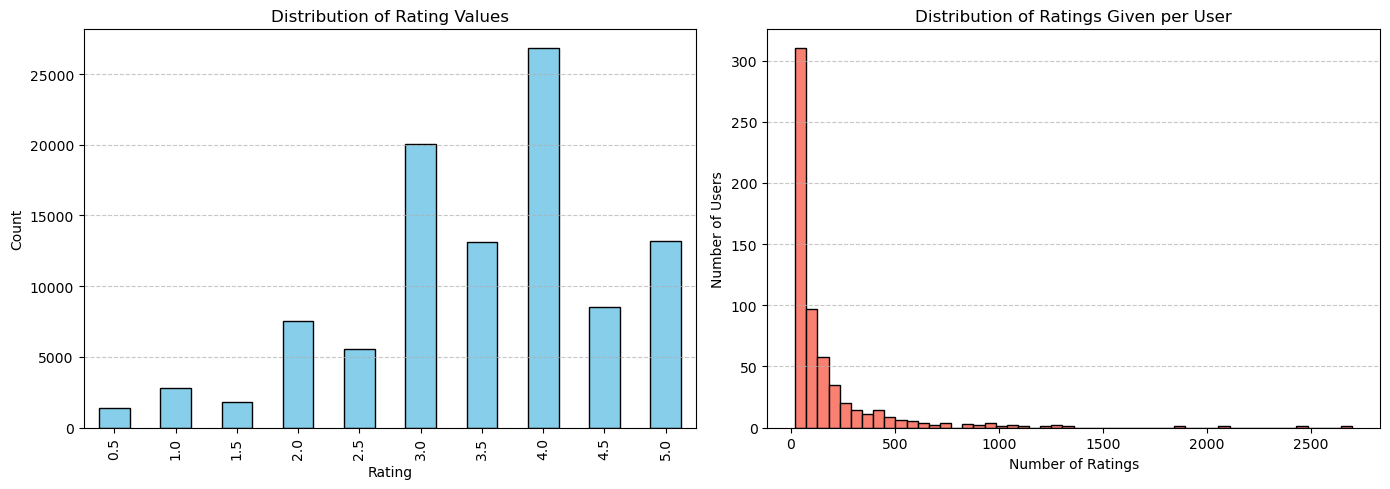

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(14,5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Distribution of Rating Values')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

user_activity = ratings.groupby('userId').size()
axes[1].hist(user_activity, bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Ratings Given per User')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Part A observations
### Rating Values:
The distribution shows a strong positive bias, with 4.0 and 3.0 being the most frequent ratings, indicating that users are more likely to rate movies they enjoy.

### User Activity:
The user activity plot reveals a long-tailed distribution where most users contribute a modest number of ratings, while a small minority act as highly active power-users


## Part B — Similarities from scratch (25 points) — B

Implement all four functions below. `axis="index"` compares users; `axis="columns"` compares items. Return aligned vectors containing only shared observed ratings. Never fill missing entries with zero for similarity computation.

Euclidean similarity: compute distance, then convert with `1/(1+d)`. Cosine: dot product divided by the product of norms. Pearson: center both co-rated vectors, then compute cosine. Basic NumPy math is permitted; prebuilt similarity/correlation routines are not.

Skip pairs with fewer than two shared observations. Decide and document zero-norm/zero-variance behavior.

**Important handout correction:** for `[5,4,5,3]` and `[3,2,3,1]`, Euclidean **distance** is 4, but the required Euclidean **similarity** is 0.2. Cosine is about 0.987164; Pearson is 1.0. Show the hand arithmetic as well as your function outputs.

In [ ]:
def get_co_rated(matrix, a, b, axis):
    """TODO: Return two aligned vectors for shared observed ratings."""
    raise NotImplementedError

def euclidean_similarity(vec1, vec2):
    """TODO: Return converted Euclidean similarity, handling undefined input."""
    raise NotImplementedError

def cosine_similarity(vec1, vec2):
    """TODO: Implement cosine using basic math."""
    raise NotImplementedError

def pearson_similarity(vec1, vec2):
    """TODO: Implement Pearson with co-rated-vector centering."""
    raise NotImplementedError

### Student-written worked-example arithmetic

TODO: Show Euclidean distance and converted similarity, cosine, and Pearson calculations.

In [ ]:
# STUDENT CHECKS — B
# TODO: Check the worked example, symmetry, scale/offset behavior,
# fewer than two observations, constant vectors, and get_co_rated on both axes.


## Part C — User-based collaborative filtering (20 points) — C

`find_k_nearest_users`: compare the target user with other users, exclude itself, skip insufficient-overlap pairs, and return up to k `(user_id, score)` pairs sorted descending.

`predict_rating_user_based`: obtain the top-k overall first, then retain those who rated the target item. Apply Section 3.5's weighted average with signed weights in the numerator and absolute weights in the denominator. Return None if none of those neighbors rated it. Handle a zero denominator sensibly.

Checks: target excluded, k larger than available neighbors, unknown IDs, no eligible raters, and a case where the nearest neighbor lacks the target rating. Do not silently substitute a baseline prediction.

In [ ]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):
    """TODO: Return descending (user_id, similarity) neighbors."""
    raise NotImplementedError

def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
    """TODO: Predict using eligible members of the top-k user neighbors."""
    raise NotImplementedError

In [ ]:
# STUDENT CHECKS AND DEMO — C
# TODO: Use a tiny hand-made matrix to verify neighbor ordering and prediction.


## Part D — Item-based collaborative filtering (15 points) — C

Adapt Part C to compare item columns over co-rating users. Select top-k item neighbors first, then retain those rated by the target user. Weight that user's ratings of those neighbors.

Reuse common logic where appropriate and explain any duplication. Verify both methods on a small matrix.

In [ ]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    """TODO: Return descending (movie_id, similarity) neighbors."""
    raise NotImplementedError

def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    """TODO: Predict from the target user's ratings of neighboring items."""
    raise NotImplementedError

In [ ]:
# STUDENT CHECKS AND DEMO — C
# TODO: Verify item-based neighbor selection and weighted prediction.


### Q12 — Student-written answer (one or two sentences)

TODO: Name the reused function/helper and explain exactly what changed between user-based and item-based CF.

## Part E — Evaluation (20 points) — A

1. Split **each user's** ratings into approximately 80% training and 20% testing. Do not use a global random split. Document rounding and ensure every user retains training data.
2. Construct `train_matrix` from training ratings only. Neither similarities nor predictions may read held-out values.
3. Attempt every held-out rating with `evaluate`. Calculate RMSE and MAE over successful predictions and report the fraction for which no prediction was possible.
4. Run all **24 configurations**: `{user, item}` × `{euclidean, cosine, pearson}` × `{5,10,20,50}`.
5. Display a table containing method, metric, k, RMSE, MAE and None fraction. Counts of test and successful predictions are useful extras.

Checks: no train/test overlap; train and test reconstruct the original observations; users retain training ratings; repeated splitting with the same seed is reproducible; RMSE is at least MAE on the same successful subset; the grid has all 24 unique combinations.

You may develop on a smaller sample, but the final table must use the full test set. A user-mean baseline and runtime columns are optional. Caching is optional; if used, preserve exact neighbor semantics and invalidate stale entries. Do not rely on an external results CSV in the submitted notebook.

In [ ]:
def train_test_split_ratings(ratings_df, test_fraction=0.2):
    """TODO: Return train_df and test_df using a per-user holdout."""
    raise NotImplementedError

def evaluate(matrix, test_df, k, similarity_fn, method):
    """TODO: Predict each held-out rating; report RMSE, MAE and None fraction."""
    raise NotImplementedError

In [ ]:
# STUDENT CODE — A
# TODO: Split ratings, construct train_matrix and verify split invariants.


In [ ]:
# STUDENT CODE — A
# TODO: Build and run the full 24-configuration grid, then display its results.


## Part F — Written analysis (15 points) — A/B/C

Write original responses based on your implementation and outputs. Do not replace them with generic definitions.

**Q16 — A:** Which metric performed best? Quote your actual RMSE/MAE results, consider coverage, and discuss agreement or disagreement with Section 3.2. Do not assume Pearson must win.

**Q17 — B:** Construct your own two-user, 3–4-item example, different from the handout, illustrating disagreement between Euclidean similarity and Pearson. Show calculations. The word “rank” is ambiguous for one pair; a literal reversal between multiple pairs is an optional extension, not an explicit extra requirement.

**Q18 — C:** For 200 million users and 20,000 products, which direction of comparison is cheaper to keep up to date? Explain the scale of comparisons, updates after new ratings, and implications for industry practice.

### Q16 — Student-written answer

TODO: Use the completed results table.

### Q17 — Student-written answer

TODO: Your original numeric example and arithmetic.

### Q18 — Student-written answer

TODO: Your reasoning about comparison and update costs.

## Optional bonus — Up to 10 extra points total

Finish the mandatory work first. The rubric allows either bonus task to be attempted.

**Bonus 1 — B:** Implement a separate mean-centered user-based predictor. Subtract each neighbor's training-rating mean before weighting and add the target user's training-rating mean afterward. Compare its RMSE with plain Pearson-weighted prediction and explain the relationship. Do not replace the mandatory predictor.

**Bonus 2 — A:** Choose a user, predict ratings for unrated movies, and show the top 10. Attach titles/genres from `movies.csv` and sanity-check the genres against that user's rating history. Document which matrix you use.

In [ ]:
# OPTIONAL STUDENT CODE
# TODO: Implement bonus tasks only if time permits.


### Student-written bonus discussion

TODO: Include only if a bonus is attempted.